# Near Surface Lapse Rate Research Project - Fourier Methods

Author : Mees Franssen, MWObs Summit Intern

In [36]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.signal as sig
import scipy.linalg as la

## Importing and verifying the datasets

Missing and otherwise erroneous data is treated with linear interpolation. Across all data it was found that missing data was minimal, with 17000 missing values across 306000 data points for all temperature data. Therefore it was deemed that linear interpolation would be appropriate. 

In [56]:
all_data = pd.read_csv(os.getcwd()+'\\arvp_summit_data_2016_2022_hourly.csv') # import the dataset
all_data['Date'] = pd.to_datetime(all_data['Date'])

# cleaning the data, getting rid of any erroneous data points, some values set to -999 to are absurdly high or show -40 degrees at the base during the summer
stations = [col for col in all_data.columns if "Temperature" in col]
all_data[stations] = all_data[stations].map(lambda x: x if pd.notna and -50<x<100 else np.nan)

t1, t2 = '2018-03-01', '2018-09-01'
mask = (all_data['Date']>=t1) & (all_data['Date']<=t2)
all_data.loc[mask, 'AR16Temperature'] = all_data.loc[mask, 'AR16Temperature'].apply(lambda x: x if x > 0 else np.nan)

# interpolating to fill in missing data
all_data.set_index(all_data['Date'], inplace=True)
all_data[stations] = all_data[stations].interpolate(method='time')

time = all_data['Date'] # get a time array
# isolate the temperatures and put them all in a big array (62000x7)
T16, T23, T33, T40, T43, T53, T63 = all_data['AR16Temperature'], all_data['AR23Temperature'], all_data['AR33Temperature'], all_data['AR40Temperature'], all_data['AR43Temperature'], all_data['AR53Temperature'], all_data['SUMTTemperature']
temperatures = np.array([np.array(T16), np.array(T23), np.array(T33), np.array(T40), np.array(T43), np.array(T53), np.array(T63)])

C:\Users\Intern\AppData\Local\Temp\ipykernel_19452\1040838684.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axs[0].set_xlim([time[0], time[-1]]), axs[0].set_ylim(-50,100)


Text(0.5, 1.0, 'Histogram of Near Surface Lapse Rate')

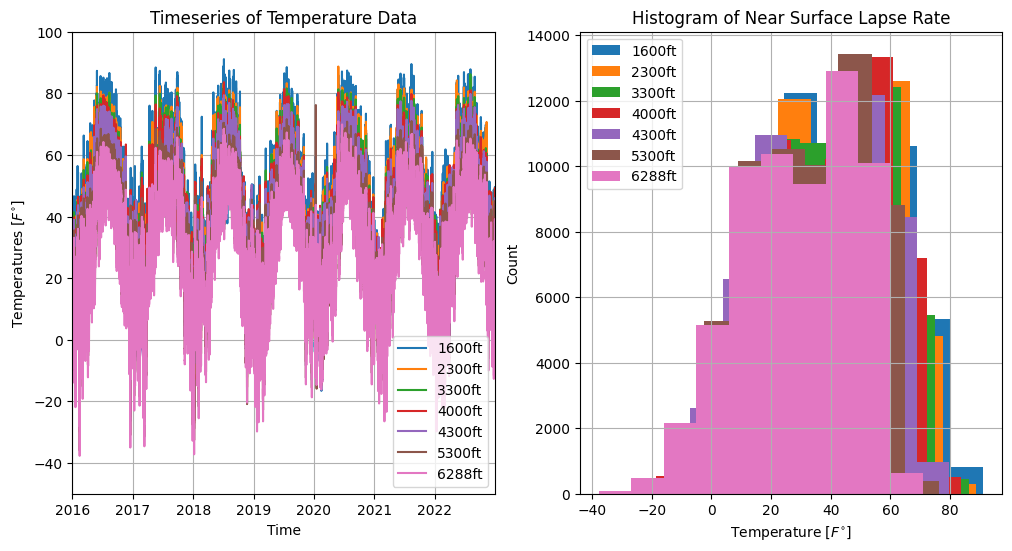

In [57]:
# making a basic plot of all the data just to see what we are working with
fig, axs = plt.subplots(ncols=2, figsize=(12,6))
titles = ['1600ft','2300ft','3300ft','4000ft','4300ft','5300ft','6288ft']
for i in range(len(temperatures)):
    axs[0].plot(time, temperatures[i], color='C'+str(i), label=titles[i])
axs[0].grid(True)
axs[0].legend()
axs[0].set_xlim([time[0], time[-1]]), axs[0].set_ylim(-50,100)
axs[0].set_xlabel('Time'), axs[0].set_ylabel('Temperatures [$F^{\\circ}$]')
axs[0].set_title('Timeseries of Temperature Data')

# making a histogram
for i in range(len(temperatures)):
    counts, bins = np.histogram(temperatures[i])
    axs[1].hist(bins[:-1], bins, weights=counts, color='C'+str(i), label=titles[i])
axs[1].grid()
axs[1].legend()
axs[1].set_ylabel('Count'), axs[1].set_xlabel('Temperature [$F^{\\circ}$]')
axs[1].set_title('Histogram of Near Surface Lapse Rate')


With the changes we made to the dataset, this looks good as far as I can tell. One possible weird moment is the 70degree spike in the winter of 2020 at 5300. I will consult with others about this and see whether it would be worth removing it from the data set. One strong benefit of fourier methods is that, in transforming to frequency space, it is somewhat impervious to single event erroneous data like this instance (given that it is really a one time event). Meaning that any error that could be carried from this won't translate to the results. Part of reliable fourier methods (particularly for hypothesis testing) necessatates looking at the autocorrelation of the data. 

To compare the power spectrum against red noise, you would need to ensure that the red noise has characteristics similar to the original timeseries (ie, comparable autocorrelation). Therefore it is necessary to observe the autocorrelation, find the e-folding timescale, and use that to estimate the alpha parameter of the red noise (lag-one autocorrelation ~ $e^{-\frac{\Delta t}{\tau}}$ where $\tau$ is the folding timescale)

Text(0.5, 1.0, 'Autocorrelation of Temperature Data')

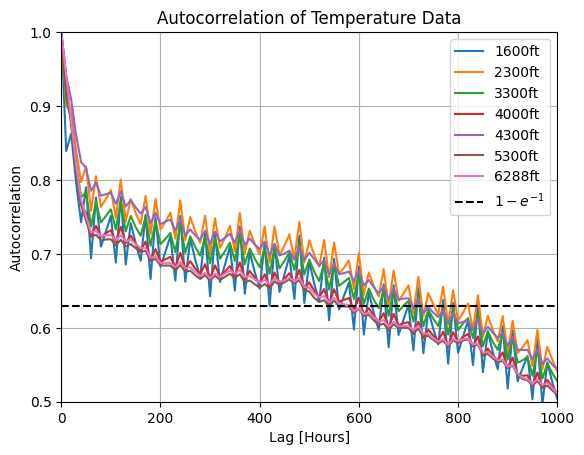

In [39]:
plt.figure()
titles = ['1600ft','2300ft','3300ft','4000ft','4300ft','5300ft','6288ft']
for i in range(len(temperatures)):
    x = temperatures[i]
    x_bar = np.mean(x)
    lags = np.arange(0,1010,10)
    auto_cov, auto_corr = np.zeros(len(lags)), np.zeros(len(lags))
    for index,lag in enumerate(lags):
        auto_cov_sum = 0
        for jndex in range(1,int(len(x)-lag)):
            auto_cov_sum += (x[jndex]-x_bar) * (x[int(jndex+lag)]-x_bar)
        auto_cov[index] = 1/len(x) * auto_cov_sum
        auto_corr[index] = 1/auto_cov[0] * auto_cov[index]
    plt.plot(lags, auto_corr, color='C'+str(i), label=titles[i])
plt.axhline(y=0.63, color='black', linestyle='dashed', label='$1-e^{-1}$')
plt.grid(True)
plt.legend(loc='upper right')
plt.xlim([0,1000]), plt.ylim([0.5,1])
plt.xlabel('Lag [Hours]'), plt.ylabel('Autocorrelation')
plt.title('Autocorrelation of Temperature Data')

From the plot a reliable estimate for the folding timescale is somewhere around 600 and 700 hours, considering the exponent, the effect either value would have on the lag-one autocorrelation is largely negligible, so a value of 650 hours can be consider representative of all the temperature data we have. From this, $\alpha = e^{-\frac{\Delta t}{\tau}} =  e^{-\frac{1}{650}} = 0.98$

In [40]:
T = len(time)         #length of time series
alpha = 0.98     #red noise lag-one autocorrelation
beta = np.sqrt(1.-alpha**2)  #beta, red noise parameter
T2 = T/8
rspec = []
for h in np.arange(0,T2+1,1):
    rspec.append((1.-alpha**2)/(1.-2.*alpha*np.cos(np.pi*(h)/T2)+alpha**2))
dof=8
fstat = st.f.ppf(.95, dof, 1000)
fspec = np.array([fstat*m for m in rspec])

#### Power Spectra
Now its time to have a look at some preliminary power spectra. I am converting to normalized power spectra (0-1), peaks in these power spectra are essentially a measure of relative fraction of variability that frequency band is responsible for. Somewhat analagous to an R-squared value. So, for example, if you have an electrical AC current at 60 Hz, you would have one spike with normalized power near 1 corresponding to 60 Hz, and random noise (very low power) at all other frequencies. For temperature data, you would expect typically two significant peaks, one corresponding to $\frac{1}{24-hours}$ (diurnal cycle) and another at $\frac{1}{364-days}$ (seasonal cycle). Given normalized power, you would expect the seasonal cycle to be most dominant. From North Conway's climatology, typical daily average temperatures in the summer versus winter vary by over 50 degrees. Then you would expect a secondary peak at the diurnal frequencies, which vary by a smaller magnitude than the seasonal 50 degree swing (typically). This is a typical temperature power spectrum, but with the elevation of mount washington, this relationship may not hold. 

#### Hypothesis testing
The statistical significance of spectral peaks is typically assessed by testing against the null hypothesis that the data is just “red noise”, i.e. it has low-frequency variability but is not periodic. The amplitude of a spectral peak is tested against the spectrum of the red noise fit to the data. Since the continuous power spectrum is a plot of variance per unit frequency, to test the statistical significance of a spectral peak, we are interested in the ratio of variances between the power spectrum of interest, and the corresponding power spectrum of red noise. The significance of this ratio can be assessed using the f-statistic. The power spectrum (and on a similar note, the normalization of the power spectrum) is calculated by exploiting the weiner-khinchin theorem: the autocorrelation function and the power spectrum of any timeseries are Fourier transforms of each other. Following the Gilman et al. methodology we can get a 95% confidence interval this way. 

The Fourier transform of any timeseries yields two degrees of freedom for its spectral peaks, for a 95% confidence interval this means the limits will be quite large, and the noise in the signal may obscure significant peaks. To make results better to interpret, and to limit noise, timeseries can be "windowed" following the Welch fast fourier transform. Essentially comparable to slicing the timeseries into $n$ samples, that overlap by $x$ percent, and are treated by some window function, in this case the Hanning window function. This increases the degrees of freedom in the power spectrum, and greatly improves confidence in results. The lowest frequency a fourier transform can reliable characterize is a direct function of the length of the timeseries, therefore one must be careful not to shorten their window length such that significant frequencies are cut (if you have a window length of a month, you can't see annual frequencies any more).

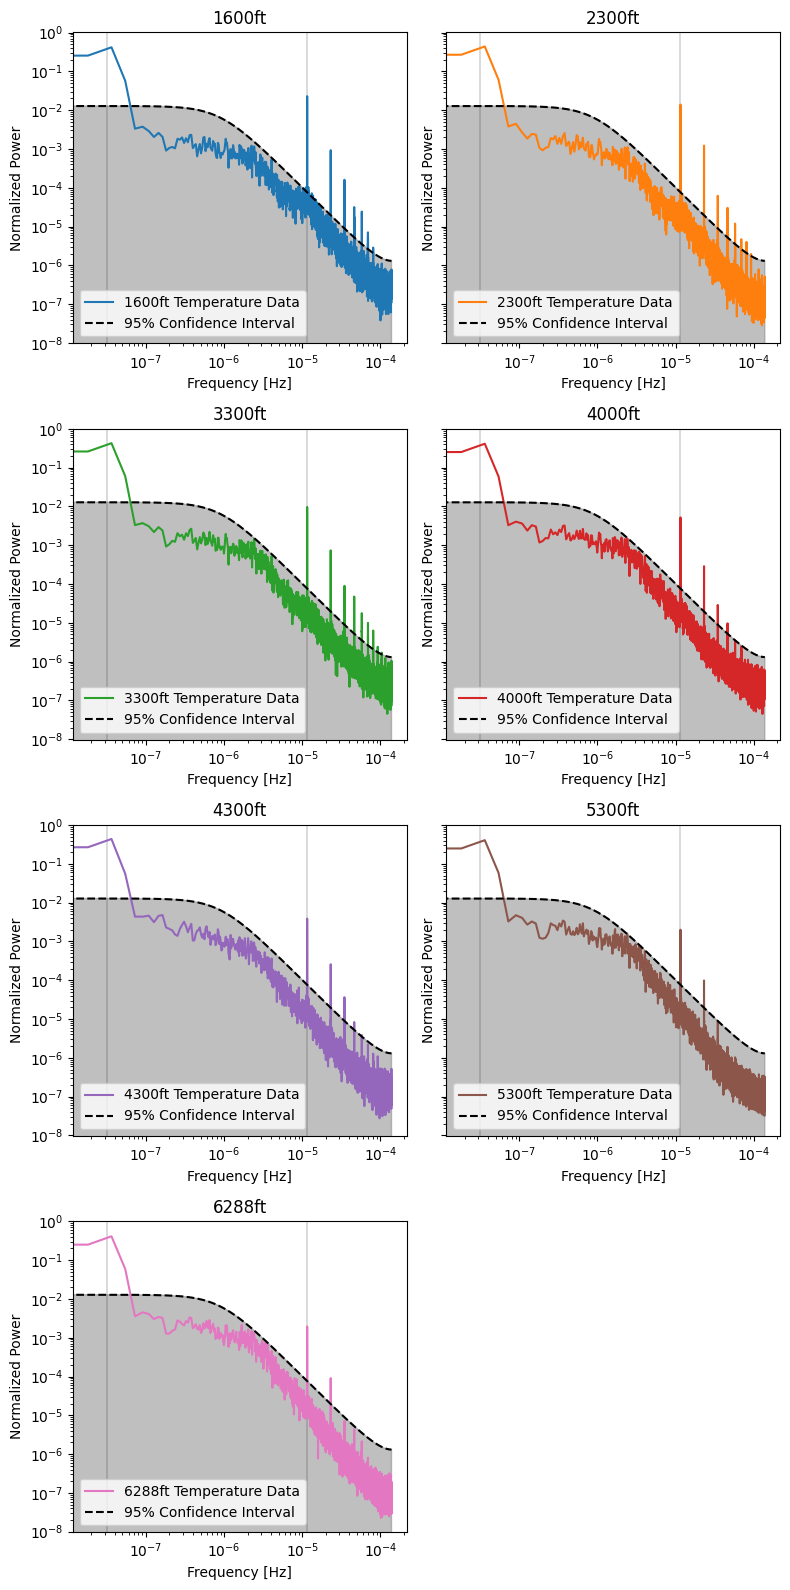

In [41]:
fig, axs = plt.subplots(4,2, figsize=(8,16), sharey=True)
axs = axs.flatten()
titles = ['1600ft','2300ft','3300ft','4000ft','4300ft','5300ft','6288ft']
for i in range(len(temperatures)):
    freqs, PSD = sig.welch(temperatures[i], fs=1/(60*60), window='hann', nperseg=len(temperatures[i])//4, noverlap=len(temperatures[i])//8)
    PSD = PSD/np.sum(PSD)
    axs[i].axvline(x=1/(365*24*60*60), color='black', linewidth=0.2)
    axs[i].axvline(x=1/(24*60*60), color='black', linewidth=0.2)
    axs[i].loglog(freqs, PSD, color='C'+str(i), label=titles[i]+' Temperature Data')
    axs[i].loglog(freqs, fspec/np.sum(fspec), color='black', linestyle='dashed', label='95% Confidence Interval')
    axs[i].fill_between(freqs, fspec/np.sum(fspec), 0, color='gray', alpha=0.5)
    axs[i].set_title(titles[i])
    axs[i].legend(loc='lower left')
    axs[i].set_ylabel('Normalized Power')
    axs[i].set_xlabel('Frequency [Hz]')
axs[7].axis('off')
fig.tight_layout()


Many of the normalized power spectra for the Mount Washington Auto Road temperature data seems to fall inline with what was expected. Namely, the strongest power is attributed to the seasonal cycle, with diurnal cycles generally holding the second most power. An interesting result is that the reslative important of the diurnal frequency appears to decrease with increasing altitude.

## Finding Lapse Rates

Lapse rates are calculated via a simple linear regression of the temperature profile data. Converting the heights from feet to kilometers, and the temperatures from fahrenheit to celsius. Linear regressions of temperature as a function of height were there calculated, where the (negative of the) gradient, $\frac{C}{km}$, is interpreted as the lapse rate. This lapse rate data is hourly. 

In [53]:
hgts = np.array([1600, 2300, 3300, 4000, 4300, 5300, 6288]) # heights of the station in feet
hgts = hgts*0.3048 # convert heights to meters
hgts = hgts/1000

temperatures = (temperatures-32)*(5/9) # convert temperatures to C
temperatures = temperatures.T # to make notation easier, transpose temperatures to be shape (61363,7) instead of (7,61383)

nslr = np.zeros(len(temperatures))

C:\Users\Intern\AppData\Local\Temp\ipykernel_19452\679128420.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axs[0].set_xlim([time[0], time[-1]]), plt.ylim([-10,20])


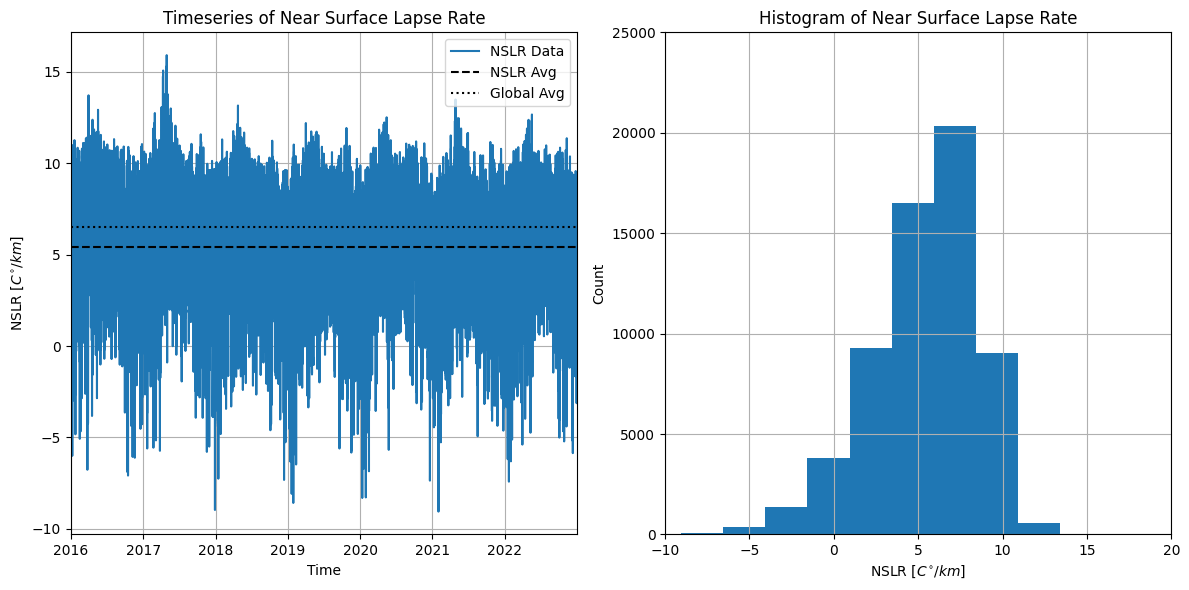

In [54]:
# regressions
for i in range(len(temperatures)):
    X = np.vstack([hgts, np.ones(7)]).T
    A = np.dot(la.inv(np.dot(X.T,X)), np.dot(X.T,temperatures[i]))
    nslr[i] = -A[0]

fig, axs = plt.subplots(ncols=2, figsize=(12,6))
axs[0].plot(time, nslr, label='NSLR Data')
axs[0].axhline(y=np.mean(nslr), color='black', linestyle='dashed', label='NSLR Avg')
axs[0].axhline(y=6.5, color='black', linestyle='dotted', label='Global Avg')
axs[0].set_xlim([time[0], time[-1]]), plt.ylim([-10,20])
axs[0].set_xlabel('Time'), axs[0].set_ylabel('NSLR [$C^{\\circ}/km$]')
axs[0].set_title('Timeseries of Near Surface Lapse Rate')
axs[0].grid(True)
axs[0].legend(loc='upper right')

# making a histogram
counts, bins = np.histogram(nslr)
axs[1].hist(bins[:-1], bins, weights=counts)
axs[1].grid()
axs[1].set_xlim([-10, 20]), axs[1].set_ylim([0,25000])
axs[1].set_ylabel('Count'), axs[1].set_xlabel('NSLR [$C^{\\circ}/km$]')
axs[1].set_title('Histogram of Near Surface Lapse Rate')

fig.tight_layout()

The timeseries of NSLR appears to be rather different than the temperature data. Namely, it appears that the annual cycle is less pronounced and there is much more short term variability. The average of the data is lower than the global average used in some models. 

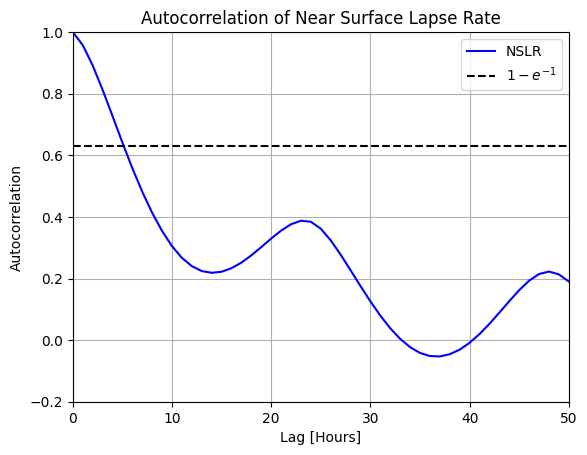

In [ ]:
x = nslr
x_bar = np.mean(x)
lags = np.arange(0,51,1)

auto_cov, auto_corr = np.zeros(len(lags)), np.zeros(len(lags))

for index,lag in enumerate(lags):
    auto_cov_sum = 0
    for i in range(1,int(len(x)-lag)):
        auto_cov_sum += (x[i]-x_bar) * (x[int(i+lag)]-x_bar)
    auto_cov[index] = 1/len(x) * auto_cov_sum
    auto_corr[index] = 1/auto_cov[0] * auto_cov[index]

plt.figure()
plt.plot(lags, auto_corr, color='blue', label='NSLR')
plt.axhline(y=0.63, color='black', linestyle='dashed', label='$1-e^{-1}$')
plt.xlim([0,50]), plt.ylim([-0.2,1])
plt.xlabel('Lag [Hours]'), plt.ylabel('Autocorrelation')
plt.grid(True)
plt.legend(loc='upper right')
plt.title('Autocorrelation of Near Surface Lapse Rate')
plt.show()


As before, the autocorrelation of the NSLR timeseries needs to be calculated such that one can characterize the red noise. Interestingly, despite NSLR determined from temperature, the NSLR data has a entirely different autocorrelation plot. With the e-folding scale to fall in lags of $\tau=6$ hours (approximately). This has cascading consequence for the red noise spectrum and, by association, the confidence interval. Namely, $\alpha = e^{-\frac{\Delta t}{\tau}} = e^{-\frac{1}{6}}=0.846$. 

In [11]:
T = len(time)         #length of time series
alpha = 0.846     #red noise lag-one autocorrelation
beta = np.sqrt(1.-alpha**2)  #beta, red noise parameter
T2 = T/8
rspec = []
for h in np.arange(0,T2+1,1):
    rspec.append((1.-alpha**2)/(1.-2.*alpha*np.cos(np.pi*(h)/T2)+alpha**2))
dof=8
fstat = st.f.ppf(.95, dof, 1000)
fspec = np.array([fstat*m for m in rspec])

Text(0.5, 1.0, 'Normalized Power Spectrum of Near-Surface Lapse Rate')

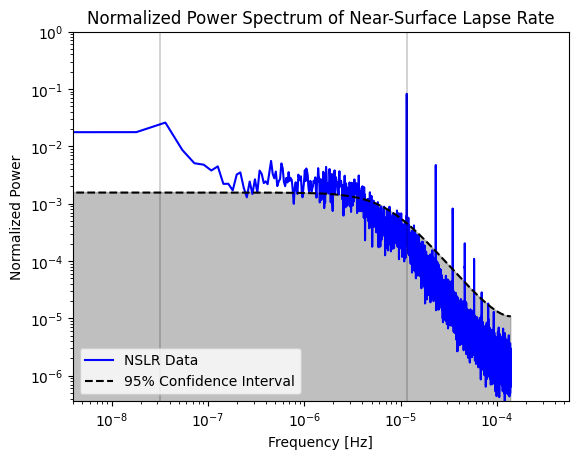

In [13]:
freqs, PSD = sig.welch(nslr, fs=1/(60*60), window='hann', nperseg=len(nslr)//4, noverlap=len(nslr)//8)
PSD = PSD/np.sum(PSD)

plt.figure()
plt.loglog(freqs, PSD, color='blue', label='NSLR Data')
plt.loglog(freqs, fspec/np.sum(fspec), color='black', linestyle='dashed', label='95% Confidence Interval')
plt.fill_between(freqs, fspec/np.sum(fspec), 0, color='gray', alpha=0.5)
plt.axvline(x=1/(365*24*60*60), color='black', linewidth=0.25)
plt.axvline(x=1/(24*60*60), color='black', linewidth=0.25)
plt.xlabel('Frequency [Hz]'), plt.ylabel('Normalized Power')
plt.ylim([min(PSD), 1]), plt.xlim([1/(8*365*24*60*60), 2/(60*60)])
plt.legend(loc='lower left')
plt.title('Normalized Power Spectrum of Near-Surface Lapse Rate')


There are some interesting differences between the NSLR spectrum and the temperature spectra. Firstly, NSLR observe its strongest normalized power in the diurnal frequency band, and a secondary peak corresponding to the seasonal cycle. The inverse to the relationship observed for temperature spectra. Secondaly, there are significant peaks in the wide frequency band between annual and diurnal frequencies. Preliminary interpretation would suggest these correspond to weather-events, varying NSLR significantly. 

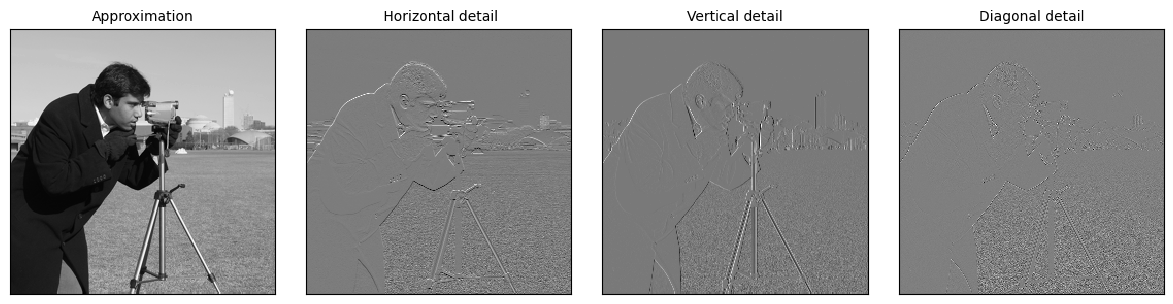

In [15]:
import pywt
import pywt.data

original = pywt.data.camera()

# Wavelet transform of image, and plot approximation and details
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
coeffs2 = pywt.dwt2(original, 'bior1.3')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()